In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZFeatureMap
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import pandas as pd
# Necessary imports


import numpy as np
import matplotlib.pyplot as plt

from torch import Tensor
from torch.nn import Linear, CrossEntropyLoss, MSELoss
from torch.optim import LBFGS

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Set seed for random generators
algorithm_globals.random_seed = 42
# Additional torch-related imports
import torch
from torch import cat, no_grad, manual_seed
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets, transforms
import torch.optim as optim
from torch.nn import (
    Module,
    Conv2d,
    Linear,
    Dropout2d,
    NLLLoss,
    MaxPool2d,
    Flatten,
    Sequential,
    ReLU,
)
import torch.nn.functional as F

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# Function to convert to 3D
def to_3d(arr):
    douaa = []
    for i in range(0, 3):
        dou = np.stack(np.stack(arr)[i], axis=-1)
        douaa.append(dou)
    douaa = np.array(douaa)
    return douaa

# Load Parquet file
parquet_file_path = 'data/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272.test.snappy.parquet'
parquet_file = pq.ParquetFile(parquet_file_path)

# Get the total number of rows
total_rows = parquet_file.metadata.num_rows

# Initialize arrays to store images and labels
images_array = []
labels_array = []

# Loop over the file in chunks
chunk_size = 50
for i in range(0, total_rows, chunk_size):
    # Read a chunk of rows from the file
    chunk = parquet_file.read_row_group(i)
    df = chunk.to_pandas()

    # Initialize arrays inside the loop
    chunk_images_array = []
    chunk_labels_array = []

    # Loop over rows in the chunk
    for j in range(len(df)):
        # Convert 'X_jets' to 3D
        df['X_jets'][j] = to_3d(df['X_jets'][j].copy())  # Use .copy() to create a copy

        # Append image and label to arrays
        chunk_images_array.append(df['X_jets'][j])
        chunk_labels_array.append(df['y'][j])

    # Append chunk data to the main arrays
    images_array.extend(chunk_images_array)
    labels_array.extend(chunk_labels_array)

# Convert arrays to NumPy arrays
images_array = np.array(images_array)
labels_array = np.array(labels_array)

<ipython-input-2-51735669484e>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['X_jets'][j] = to_3d(df['X_jets'][j].copy())  # Use .copy() to create a copy
<ipython-input-2-51735669484e>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['X_jets'][j] = to_3d(df['X_jets'][j].copy())  # Use .copy() to create a copy
<ipython-input-2-51735669484e>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['X_jets'][j] = to_3d(df['X_jets']

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
train_images, test_images, train_labels, test_labels = train_test_split(
    images_array, labels_array, test_size=0.3
)

print(train_images.shape)
print(train_labels.shape)

(508, 3, 125, 125)
(508,)


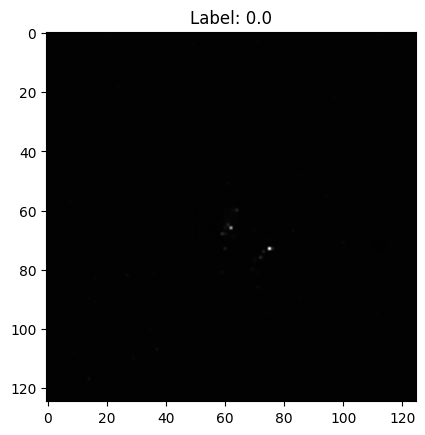

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
import numpy as np
import matplotlib.pyplot as plt

# Assuming images_array has shape (726, 3, 125, 125)
# Reduce dimensions for plotting (taking the mean across channels)
reduced_images_array = np.mean(train_images, axis=1)

# Plotting example images
num_images_to_plot = 1
for i in range(num_images_to_plot):
    plt.imshow(reduced_images_array[i], cmap='gray')  # Displaying the mean across channels
    plt.title(f"Label: {labels_array[i]}")
    plt.show()

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
import numpy as np
from scipy.ndimage import zoom

# Assuming your images are stored in a variable named 'images'
# 'images' is assumed to be of shape (num_samples, 125, 125)

# Define the target shape
target_shape = (125, 125)

# Initialize an empty array to store resized images
resized_images = np.zeros((reduced_images_array.shape[0], *target_shape))

# Loop through each image and resize
for i in range(reduced_images_array.shape[0]):
    resized_images[i] = zoom(reduced_images_array[i], (target_shape[0] / reduced_images_array.shape[1], target_shape[1] / reduced_images_array.shape[2]))

# Now, 'resized_images' contains your images of shape (num_samples, 40, 40)
print(resized_images.shape)

(508, 125, 125)


In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
import torch

import torch
from torchvision import transforms

#transforming 
resized_images = resized_images.astype(np.float32)
train_labels = train_labels.astype(np.float32)
# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Convert the NumPy array to a PyTorch tensor
tensor_images = torch.stack([transform(img) for img in resized_images])

label_transform = transforms.Compose([
    transforms.Lambda(lambda x: torch.tensor(x, dtype=torch.float32)),  # Adjust the dtype if needed
])

# Convert the NumPy array of labels to a PyTorch tensor
tensor_labels = label_transform(train_labels).long()
# tensor_images.shape will be (num_samples, num_channels, height, width)
# In this case, num_channels will be 1, assuming the images are grayscale.


# Assuming numpy_images and numpy_labels are your NumPy arrays
#torch_images = torch.from_numpy(resized_images).float()
#torch_labels = torch.from_numpy(train_labels).long()

class CustomDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    
batch_size = 1  # Adjust as needed
shuffle = True   # You can set this to False if you want to disable shuffling

custom_dataset = CustomDataset(tensor_images, tensor_labels)
train_loader = DataLoader(custom_dataset, batch_size=batch_size, shuffle=shuffle)

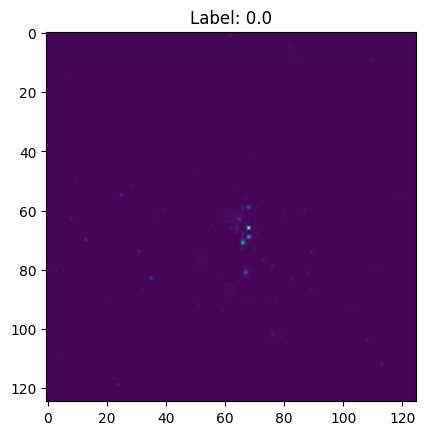

In [7]:
# --- [CELL 6]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# === BEFORE (original) ===
# plt.imshow(custom_dataset.images[1][0, :, :])  # Displaying the first channel of the image
# plt.imshow(custom_dataset.labels[0])  # Displaying the first channel of the image
# 
# plt.title(f"Label: {labels_array[1]}")
# plt.show()

# === AFTER (edited) ===
import matplotlib.pyplot as plt

plt.imshow(custom_dataset.images[1][0, :, :])

plt.title(f"Label: {labels_array[1]}")
plt.show()